<a href="https://colab.research.google.com/github/shomere/formative_2group3_ml_techs1_swac/blob/main/Swahiliaudio_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = '/content/drive/MyDrive/Swahili_Audio_Project'
for sub in ['results', 'models', 'submissions']:
    os.makedirs(f'{BASE}/{sub}', exist_ok=True)
print("Base dir ready:", BASE)

Mounted at /content/drive
Base dir ready: /content/drive/MyDrive/Swahili_Audio_Project


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, regularizers
from tensorflow.keras.utils import to_categorical

In [5]:
import gdown
import os

ZIP_PATH = '/content/w1.5_energy_mfcc40_d.zip'
file_id = '1DgKUc3GS8wLurzY_6hS9MizRLKEQnXWl'
url = f'https://drive.google.com/uc?id={file_id}'

# Download the dataset directly to Colab if it does not exist
if not os.path.exists(ZIP_PATH):
    print("Downloading zip file from Google Drive...")
    gdown.download(url, ZIP_PATH, quiet=False)
else:
    print("Zip file already exists.")

print("Checking path:", ZIP_PATH)
print("Exists:", os.path.exists(ZIP_PATH))
if os.path.exists(ZIP_PATH):
    print("Size (MB):", round(os.path.getsize(ZIP_PATH) / 1e6, 2))

Downloading...
From (original): https://drive.google.com/uc?id=1DgKUc3GS8wLurzY_6hS9MizRLKEQnXWl
From (redirected): https://drive.google.com/uc?id=1DgKUc3GS8wLurzY_6hS9MizRLKEQnXWl&confirm=t&uuid=17f6dd5a-46d6-4358-9948-6ba2f23942a1
To: /content/w1.5_energy_mfcc40_d.zip
100%|██████████| 277M/277M [00:09<00:00, 29.7MB/s]

Checking path: /content/w1.5_energy_mfcc40_d.zip
Exists: True
Size (MB): 277.49


In [6]:
import gdown

# Google Drive file ID from your link
file_id = '1DgKUc3GS8wLurzY_6hS9MizRLKEQnXWl'
url = f'https://drive.google.com/uc?id={file_id}'
output = '/content/w1.5_energy_mfcc40_d.zip'

# Download the dataset directly to Colab
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1DgKUc3GS8wLurzY_6hS9MizRLKEQnXWl
From (redirected): https://drive.google.com/uc?id=1DgKUc3GS8wLurzY_6hS9MizRLKEQnXWl&confirm=t&uuid=4b4b08e4-94e2-4dd7-8cde-c8c6434db8d6
To: /content/w1.5_energy_mfcc40_d.zip
100%|██████████| 277M/277M [00:07<00:00, 38.0MB/s]


'/content/w1.5_energy_mfcc40_d.zip'

In [7]:
import zipfile, time, os

EXTRACT_DIR = '/content/dataset'
os.makedirs(EXTRACT_DIR, exist_ok=True)

t0 = time.time()
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)
print(f"Extracted in {time.time()-t0:.1f}s")

Extracted in 0.7s


In [8]:
DATA_DIR = None
for root, dirs, files in os.walk(EXTRACT_DIR):
    if 'train.npz' in files:
        DATA_DIR = root
        break

assert DATA_DIR is not None, "train.npz not found"
print("DATA_DIR =", DATA_DIR)
for f in sorted(os.listdir(DATA_DIR)):
    p = os.path.join(DATA_DIR, f)
    if os.path.isfile(p):
        print(f"  {f}  ({os.path.getsize(p)/1e6:.2f} MB)")

DATA_DIR = /content/dataset/w1.5_energy_mfcc40_d
  labels.json  (0.00 MB)
  test.npz  (41.63 MB)
  train.npz  (194.21 MB)
  val.npz  (41.60 MB)


In [9]:
import json, numpy as np

with open(os.path.join(DATA_DIR, 'labels.json')) as f:
    LABELS = json.load(f)
print("labels.json:", LABELS)

for name in ['train', 'val', 'test']:
    d = np.load(os.path.join(DATA_DIR, f'{name}.npz'), allow_pickle=True)
    print(f"\n=== {name}.npz ===")
    for k in d.files:
        print(f"  {k}: shape={d[k].shape}, dtype={d[k].dtype}")

labels.json: {'hapana': 0, 'kumi': 1, 'mbili': 2, 'moja': 3, 'nane': 4, 'ndio': 5, 'nne': 6, 'saba': 7, 'sita': 8, 'tano': 9, 'tatu': 10, 'tisa': 11}

=== train.npz ===
  X: shape=(2940, 151, 120), dtype=float32
  y: shape=(2940,), dtype=int64
  ids: shape=(2940,), dtype=object

=== val.npz ===
  X: shape=(630, 151, 120), dtype=float32
  y: shape=(630,), dtype=int64
  ids: shape=(630,), dtype=object

=== test.npz ===
  X: shape=(630, 151, 120), dtype=float32
  y: shape=(630,), dtype=int64
  ids: shape=(630,), dtype=object


In [10]:
train_npz = np.load(os.path.join(DATA_DIR, 'train.npz'), allow_pickle=True)
val_npz   = np.load(os.path.join(DATA_DIR, 'val.npz'),   allow_pickle=True)
test_npz  = np.load(os.path.join(DATA_DIR, 'test.npz'),  allow_pickle=True)

def pick(npz, candidates, label='array'):
    for c in candidates:
        if c in npz.files:
            return c
    raise KeyError(f"No {label} key. Tried {candidates}. Available: {npz.files}")

XK = ['X', 'mfcc', 'features', 'X_mfcc', 'mel', 'spectrograms']
yK = ['y', 'labels', 'targets']

X_train = train_npz[pick(train_npz, XK, 'X')]
y_train = train_npz[pick(train_npz, yK, 'y')]
X_val   = val_npz[pick(val_npz, XK, 'X')]
y_val   = val_npz[pick(val_npz, yK, 'y')]
X_test  = test_npz[pick(test_npz, XK, 'X')]

idx_to_label = {v: k for k, v in LABELS.items()}
CLASS_NAMES  = [idx_to_label[i] for i in range(len(LABELS))]
NUM_CLASSES  = len(CLASS_NAMES)

# Safety: if y came as one-hot, flatten
if y_train.ndim > 1 and y_train.shape[1] == NUM_CLASSES:
    y_train = np.argmax(y_train, axis=1)
    y_val   = np.argmax(y_val,   axis=1)

print("Class order:", CLASS_NAMES)
print("Shapes:")
print("  X_train:", X_train.shape, "y_train:", y_train.shape)
print("  X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print("  X_test :", X_test.shape)

Class order: ['hapana', 'kumi', 'mbili', 'moja', 'nane', 'ndio', 'nne', 'saba', 'sita', 'tano', 'tatu', 'tisa']
Shapes:
  X_train: (2940, 151, 120) y_train: (2940,)
  X_val  : (630, 151, 120) y_val  : (630,)
  X_test : (630, 151, 120)


In [11]:
def to_seq_format(X, feat_candidates=(40, 41, 120)): # Added 120 to feat_candidates
    F = X.shape[-1]
    if F in feat_candidates:
        print(f"Already (N, T, F) with F={F}: {X.shape}")
        return X
    # look for the feature axis elsewhere
    for axis in [1, 2]:
        if X.shape[axis] in feat_candidates:
            X = np.transpose(X, (0, 2, 1)) if axis == 1 else X
            print(f"Reordered axis {axis} -> (N, T, F): {X.shape}")
            return X
    raise ValueError(f"Cannot locate feature axis in {X.shape}")

X_train = to_seq_format(X_train)
X_val   = to_seq_format(X_val)
X_test  = to_seq_format(X_test)

TIMESTEPS  = X_train.shape[1]
N_FEATURES = X_train.shape[2]
print(f"\nTIMESTEPS = {TIMESTEPS}, N_FEATURES = {N_FEATURES}")

Already (N, T, F) with F=120: (2940, 151, 120)
Already (N, T, F) with F=120: (630, 151, 120)
Already (N, T, F) with F=120: (630, 151, 120)

TIMESTEPS = 151, N_FEATURES = 120


In [12]:
mean = X_train.mean()
std  = X_train.std()

X_train = ((X_train - mean) / (std + 1e-8)).astype(np.float32)
X_val   = ((X_val   - mean) / (std + 1e-8)).astype(np.float32)
X_test  = ((X_test  - mean) / (std + 1e-8)).astype(np.float32)
print("Post-norm train mean/std:", X_train.mean().round(4), X_train.std().round(4))

Post-norm train mean/std: 0.0 1.0


In [13]:
from tensorflow.keras.utils import to_categorical

y_train_oh = to_categorical(y_train, NUM_CLASSES)
y_val_oh   = to_categorical(y_val,   NUM_CLASSES)
print("y_train_oh:", y_train_oh.shape, "| y_val_oh:", y_val_oh.shape)

y_train_oh: (2940, 12) | y_val_oh: (630, 12)


In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))

def build_gru(T, F, C, gru1=128, gru2=64, dropout=0.4, lr=1e-3):
    inp = layers.Input(shape=(T, F), name='input')
    x = layers.GRU(gru1, return_sequences=True)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    x = layers.GRU(gru2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout * 0.5)(x)
    out = layers.Dense(C, activation='softmax')(x)

    m = models.Model(inp, out)
    m.compile(optimizer=optimizers.Adam(lr),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
    return m

model = build_gru(TIMESTEPS, N_FEATURES, NUM_CLASSES)
model.summary()

TF: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 151, 120)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 151, 128)       │        96,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 151, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 151, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,956 (542.80 KB)

 Trainable params: 138,572 (541.30 KB)

 Non-trainable params: 384 (1.50 KB)

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, regularizers

class SpecAugment(layers.Layer):
    def __init__(self, freq_mask=8, time_mask=10, n_masks=2, **kwargs):
        super(SpecAugment, self).__init__(**kwargs)
        self.freq_mask = freq_mask
        self.time_mask = time_mask
        self.n_masks = n_masks

    def call(self, inputs, training=None):
        if not training:
            return inputs

        # Unpack shape
        shape = tf.shape(inputs)
        num_frames = shape[1]
        num_freqs = shape[2]

        masked_inputs = inputs
        for _ in range(self.n_masks):
            # Frequency mask
            f_width = tf.random.uniform([], minval=0, maxval=self.freq_mask, dtype=tf.int32)
            f_start = tf.random.uniform([], minval=0, maxval=num_freqs - f_width, dtype=tf.int32)
            f_indices = tf.range(num_freqs)
            f_mask = tf.cast((f_indices < f_start) | (f_indices >= f_start + f_width), dtype=tf.float32)
            masked_inputs = masked_inputs * f_mask[tf.newaxis, tf.newaxis, :]

            # Time mask
            t_width = tf.random.uniform([], minval=0, maxval=self.time_mask, dtype=tf.int32)
            t_start = tf.random.uniform([], minval=0, maxval=num_frames - t_width, dtype=tf.int32)
            t_indices = tf.range(num_frames)
            t_mask = tf.cast((t_indices < t_start) | (t_indices >= t_start + t_width), dtype=tf.float32)
            masked_inputs = masked_inputs * t_mask[tf.newaxis, :, tf.newaxis]

        return masked_inputs

    def get_config(self):
        config = super(SpecAugment, self).get_config()
        config.update({
            "freq_mask": self.freq_mask,
            "time_mask": self.time_mask,
            "n_masks": self.n_masks
        })
        return config

def build_bigru(T, F, C,
                gru1=96, gru2=48,
                dropout=0.5, l2=1e-4, input_noise=0.01, lr=1e-3):
    reg = regularizers.l2(l2)

    inp = layers.Input(shape=(T, F), name='input')

    # Augmentation
    x = layers.GaussianNoise(input_noise)(inp)
    x = SpecAugment(freq_mask=8, time_mask=10, n_masks=2, name='specaug')(x)

    # BiGRU stack
    x = layers.Bidirectional(
        layers.GRU(gru1, return_sequences=True, kernel_regularizer=reg)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    x = layers.Bidirectional(
        layers.GRU(gru2, kernel_regularizer=reg)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    # Classifier head
    x = layers.Dense(64, activation='relu', kernel_regularizer=reg)(x)
    x = layers.Dropout(dropout * 0.6)(x)
    out = layers.Dense(C, activation='softmax')(x)

    m = models.Model(inp, out)
    m.compile(optimizer=optimizers.Adam(lr),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
    return m

model = build_bigru(TIMESTEPS, N_FEATURES, NUM_CLASSES)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 151, 120)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_2                │ (None, 151, 120)       │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ specaug (SpecAugment)           │ (None, 151, 120)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 151, 192)       │       125,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 151, 192)       │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 151, 192)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 96)             │        69,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,404 (794.55 KB)

 Trainable params: 202,828 (792.30 KB)

 Non-trainable params: 576 (2.25 KB)

In [18]:
CKPT = f'{BASE}/models/best_gru_mfcc.keras'

cbs = [
    callbacks.ModelCheckpoint(CKPT, monitor='val_accuracy',
                              save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=10,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=4, min_lr=1e-6, verbose=1),
]

history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=60,
    batch_size=64,
    callbacks=cbs,
    verbose=1,
)

Epoch 1/60
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0842 - loss: 3.4454
Epoch 1: val_accuracy improved from None to 0.08889, saving model to /content/drive/MyDrive/Swahili_Audio_Project/models/best_gru_mfcc.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Swahili_Audio_Project/models/best_gru_mfcc.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step - accuracy: 0.0925 - loss: 3.3019 - val_accuracy: 0.0889 - val_loss: 2.5725 - learning_rate: 0.0010
Epoch 2/60
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1058 - loss: 3.0172
Epoch 2: val_accuracy improved from 0.08889 to 0.10952, saving model to /content/drive/MyDrive/Swahili_Audio_Project/models/best_gru_mfcc.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Swahili_Audio_Project/models/best_gru_mfcc.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.1075 - loss: 2.9811 - val_accuracy: 0.1095 - val_loss: 2.5257 - learning_rate: 0.0010
Epoch 3/60
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

Val Accuracy: 0.9429
Val Macro-F1: 0.9428

              precision    recall  f1-score   support

      hapana       0.98      0.98      0.98        53
        kumi       0.96      0.90      0.93        52
       mbili       0.96      0.89      0.92        53
        moja       0.96      0.96      0.96        52
        nane       0.96      0.88      0.92        52
        ndio       0.88      0.96      0.92        53
         nne       0.89      0.96      0.93        52
        saba       0.95      1.00      0.97        52
        sita       0.96      0.96      0.96        53
        tano       0.96      0.92      0.94        53
        tatu       0.94      0.94      0.94        53
        tisa       0.92      0.94      0.93        52

    accuracy                           0.94       630
   macro avg       0.94      0.94      0.94       630
weighted avg       0.94      0.94      0.94       630



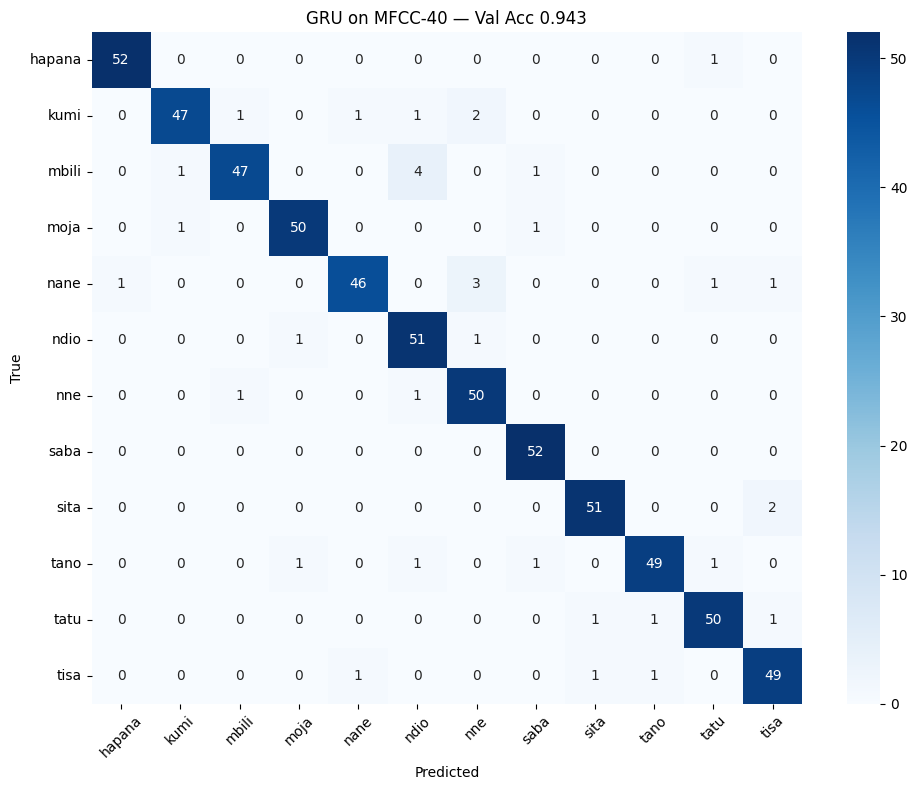

In [19]:
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
acc = accuracy_score(y_val, y_pred)
f1  = f1_score(y_val, y_pred, average='macro')

print(f"Val Accuracy: {acc:.4f}")
print(f"Val Macro-F1: {f1:.4f}\n")
print(classification_report(y_val, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'GRU on MFCC-40 — Val Acc {acc:.3f}')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{BASE}/results/gru_mfcc_confusion.png', dpi=150)
plt.show()

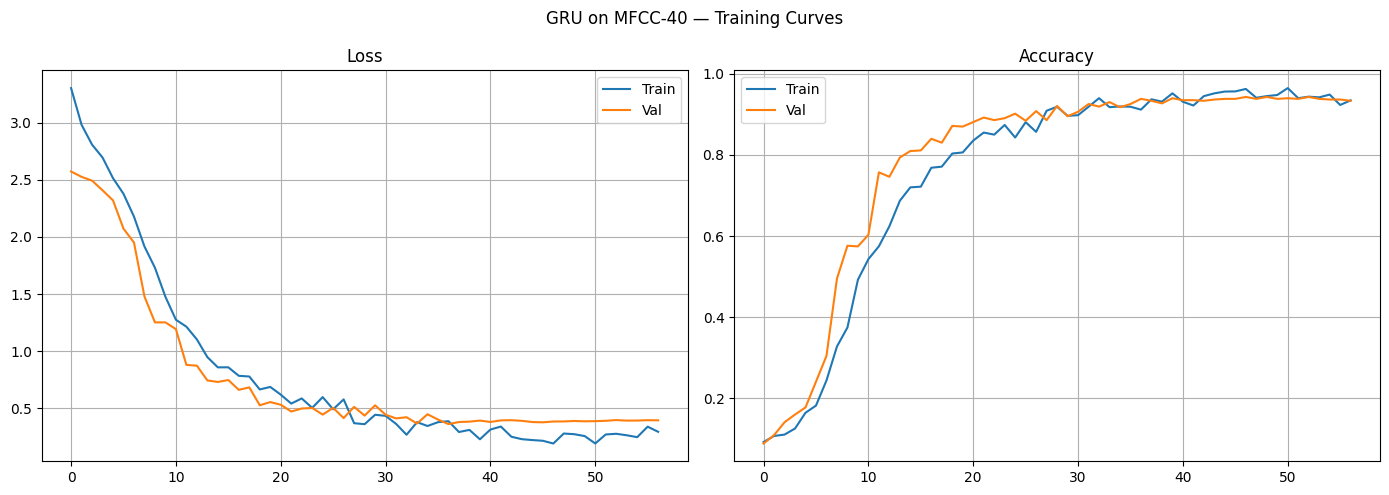

Results CSV saved.


In [20]:
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.suptitle('GRU on MFCC-40 — Training Curves')
plt.tight_layout()
plt.savefig(f'{BASE}/results/gru_mfcc_learning_curves.png', dpi=150)
plt.show()

pd.DataFrame([{
    'model': 'GRU (MFCC-40)',
    'val_accuracy': acc,
    'val_macro_f1': f1,
    'epochs_trained': len(history.history['loss']),
    'params': model.count_params(),
}]).to_csv(f'{BASE}/results/gru_mfcc_results.csv', index=False)
print("Results CSV saved.")

In [21]:
test_probs = model.predict(X_test, verbose=0)
print("Test probs shape:", test_probs.shape)

# Column order
sample_sub_path = os.path.join(DATA_DIR, 'SampleSubmission.csv')
if os.path.exists(sample_sub_path):
    class_cols = list(pd.read_csv(sample_sub_path, nrows=0).columns[1:])
else:
    class_cols = CLASS_NAMES
print("Submission columns:", class_cols)

col_idx = [CLASS_NAMES.index(c) for c in class_cols]
probs_ordered = test_probs[:, col_idx]

# IDs
id_keys = ['Word_id', 'word_ids', 'ids', 'id']
test_ids = None
if any(k in test_npz.files for k in id_keys):
    test_ids = test_npz[pick(test_npz, id_keys, 'IDs')]
    print("IDs from test.npz")
elif os.path.exists(os.path.join(DATA_DIR, 'Test.csv')):
    test_ids = pd.read_csv(os.path.join(DATA_DIR, 'Test.csv'))['Word_id'].values
    print("IDs from Test.csv")

# If still missing, warn but don't fail (still saves a positional submission)
if test_ids is None:
    print("WARNING: no test IDs found — using positional index")
    test_ids = [f'test_{i}.wav' for i in range(len(probs_ordered))]

sub = pd.DataFrame({'Word_id': test_ids})
for j, c in enumerate(class_cols):
    sub[c] = probs_ordered[:, j]

print(sub.head())
print("Row sums:", sub[class_cols].sum(axis=1).describe().round(4))

sub.to_csv(f'{BASE}/submissions/gru_mfcc_submission.csv', index=False)
print("Saved:", f'{BASE}/submissions/gru_mfcc_submission.csv')

Test probs shape: (630, 12)
Submission columns: ['hapana', 'kumi', 'mbili', 'moja', 'nane', 'ndio', 'nne', 'saba', 'sita', 'tano', 'tatu', 'tisa']
IDs from test.npz
               Word_id    hapana          kumi         mbili          moja  \
0  id_v8rz06e6rv31.wav  0.000002  1.282021e-04  9.994476e-01  2.882636e-07   
1  id_twhce0u5wcg0.wav  0.999704  8.939440e-07  2.866129e-08  9.466663e-05   
2  id_3komqnffiaet.wav  0.000548  1.035397e-06  1.031873e-08  9.994142e-01   
3  id_lbhxpmz7zdxl.wav  0.000001  1.651433e-07  1.139948e-07  2.489935e-05   
4  id_giv6yxiwwxsw.wav  0.067616  4.594581e-03  1.217512e-02  3.121198e-01   

           nane          ndio           nne          saba          sita  \
0  3.489152e-05  1.482210e-04  2.185659e-04  2.403227e-08  5.872539e-06   
1  8.984379e-07  2.496838e-07  4.295712e-07  9.697321e-06  1.819235e-08   
2  1.297332e-05  8.309861e-07  1.922122e-05  3.294931e-06  5.877135e-09   
3  9.998170e-01  4.653024e-08  1.501715e-04  8.329728e-08  3.02870

Test Accuracy : 0.9302
Test Macro-F1 : 0.9296

              precision    recall  f1-score   support

      hapana       0.92      0.92      0.92        52
        kumi       0.95      1.00      0.97        53
       mbili       0.98      0.92      0.95        52
        moja       0.91      0.94      0.93        53
        nane       0.96      0.96      0.96        53
        ndio       0.91      0.94      0.92        52
         nne       0.95      0.79      0.87        53
        saba       0.89      0.94      0.92        53
        sita       0.98      0.94      0.96        52
        tano       0.88      0.87      0.87        52
        tatu       0.89      0.94      0.92        52
        tisa       0.95      0.98      0.96        53

    accuracy                           0.93       630
   macro avg       0.93      0.93      0.93       630
weighted avg       0.93      0.93      0.93       630



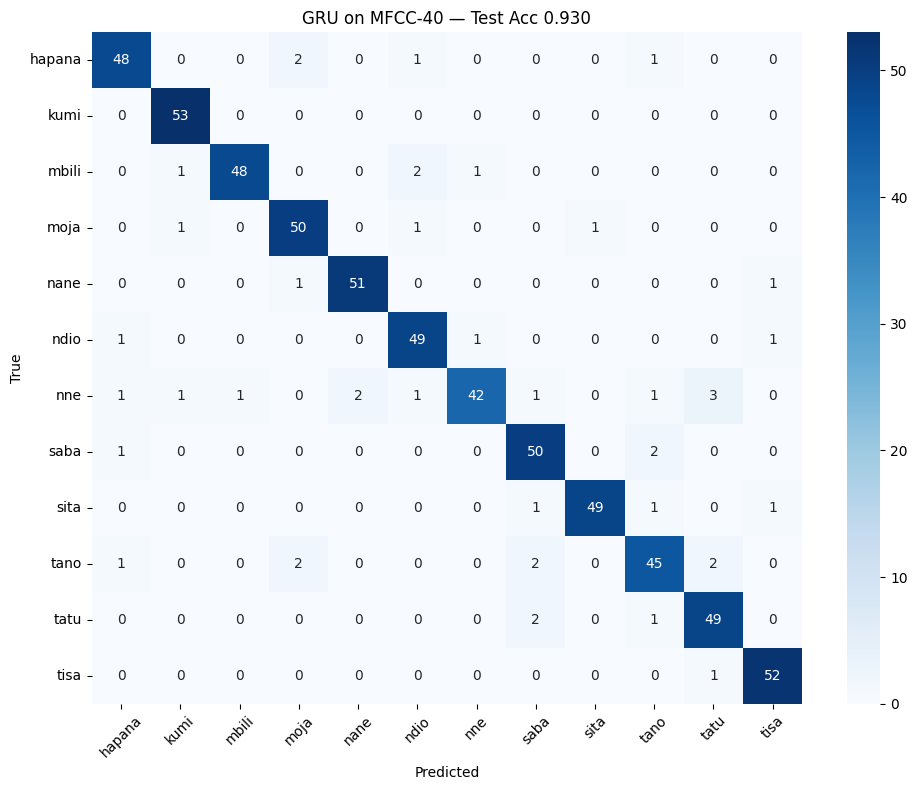

Test results CSV saved.


In [22]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

test_npz_reload = np.load(os.path.join(DATA_DIR, 'test.npz'), allow_pickle=True)
y_test = test_npz_reload['y']

y_pred_test = np.argmax(model.predict(X_test, verbose=0), axis=1)
test_acc = accuracy_score(y_test, y_pred_test)
test_f1  = f1_score(y_test, y_pred_test, average='macro')

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Macro-F1 : {test_f1:.4f}\n")
print(classification_report(y_test, y_pred_test, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'GRU on MFCC-40 — Test Acc {test_acc:.3f}')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{BASE}/results/gru_mfcc_test_confusion.png', dpi=150)
plt.show()

import pandas as pd
pd.DataFrame([{
    'model': 'GRU (MFCC-40)',
    'test_accuracy': test_acc,
    'test_macro_f1': test_f1,
}]).to_csv(f'{BASE}/results/gru_mfcc_test_results.csv', index=False)
print("Test results CSV saved.")


Test Accuracy : 0.9302
Test Macro-F1 : 0.9296

              precision    recall  f1-score   support

      hapana       0.92      0.92      0.92        52
        kumi       0.95      1.00      0.97        53
       mbili       0.98      0.92      0.95        52
        moja       0.91      0.94      0.93        53
        nane       0.96      0.96      0.96        53
        ndio       0.91      0.94      0.92        52
         nne       0.95      0.79      0.87        53
        saba       0.89      0.94      0.92        53
        sita       0.98      0.94      0.96        52
        tano       0.88      0.87      0.87        52
        tatu       0.89      0.94      0.92        52
        tisa       0.95      0.98      0.96        53

    accuracy                           0.93       630
   macro avg       0.93      0.93      0.93       630
weighted avg       0.93      0.93      0.93       630



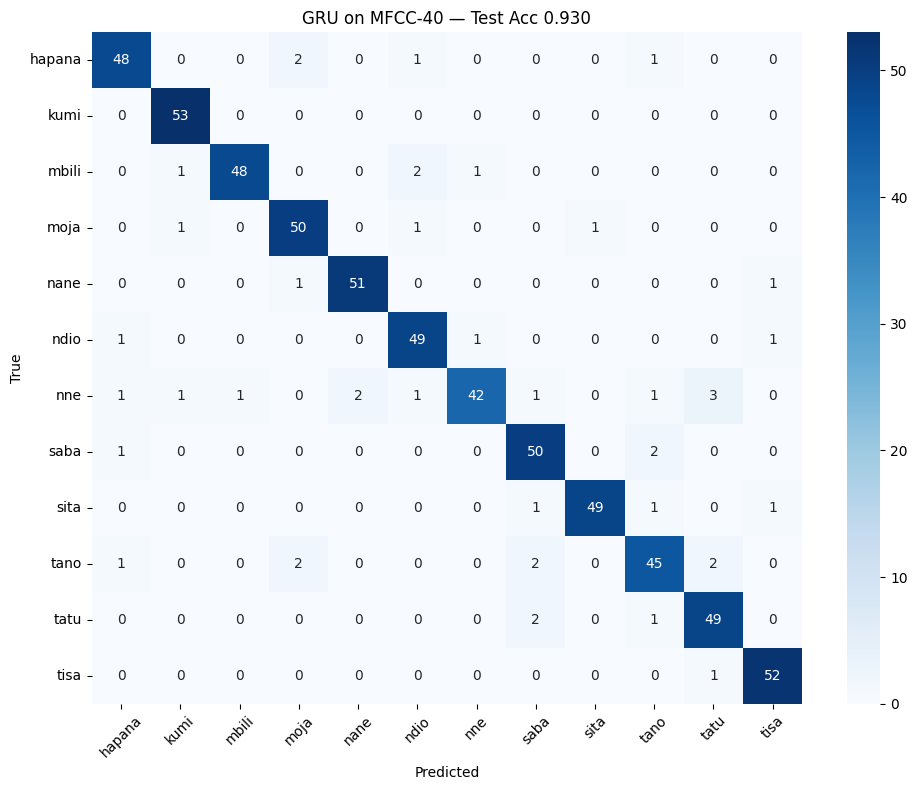

Test results CSV saved.


In [23]:
# ── Test-set evaluation on the labelled held-out split ──────────────────────
test_npz_reload = np.load(os.path.join(DATA_DIR, 'test.npz'), allow_pickle=True)
y_test = test_npz_reload['y']

y_pred_test = np.argmax(model.predict(X_test, verbose=0), axis=1)
test_acc = accuracy_score(y_test, y_pred_test)
test_f1  = f1_score(y_test, y_pred_test, average='macro')

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Macro-F1 : {test_f1:.4f}\n")
print(classification_report(y_test, y_pred_test, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'GRU on MFCC-40 — Test Acc {test_acc:.3f}')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{BASE}/results/gru_mfcc_test_confusion.png', dpi=150)
plt.show()

pd.DataFrame([{
    'model': 'GRU (MFCC-40)',
    'test_accuracy': test_acc,
    'test_macro_f1': test_f1,
}]).to_csv(f'{BASE}/results/gru_mfcc_test_results.csv', index=False)
print("Test results CSV saved.")

Test Accuracy : 0.9302
Test Macro-F1 : 0.9296

              precision    recall  f1-score   support

      hapana       0.92      0.92      0.92        52
        kumi       0.95      1.00      0.97        53
       mbili       0.98      0.92      0.95        52
        moja       0.91      0.94      0.93        53
        nane       0.96      0.96      0.96        53
        ndio       0.91      0.94      0.92        52
         nne       0.95      0.79      0.87        53
        saba       0.89      0.94      0.92        53
        sita       0.98      0.94      0.96        52
        tano       0.88      0.87      0.87        52
        tatu       0.89      0.94      0.92        52
        tisa       0.95      0.98      0.96        53

    accuracy                           0.93       630
   macro avg       0.93      0.93      0.93       630
weighted avg       0.93      0.93      0.93       630



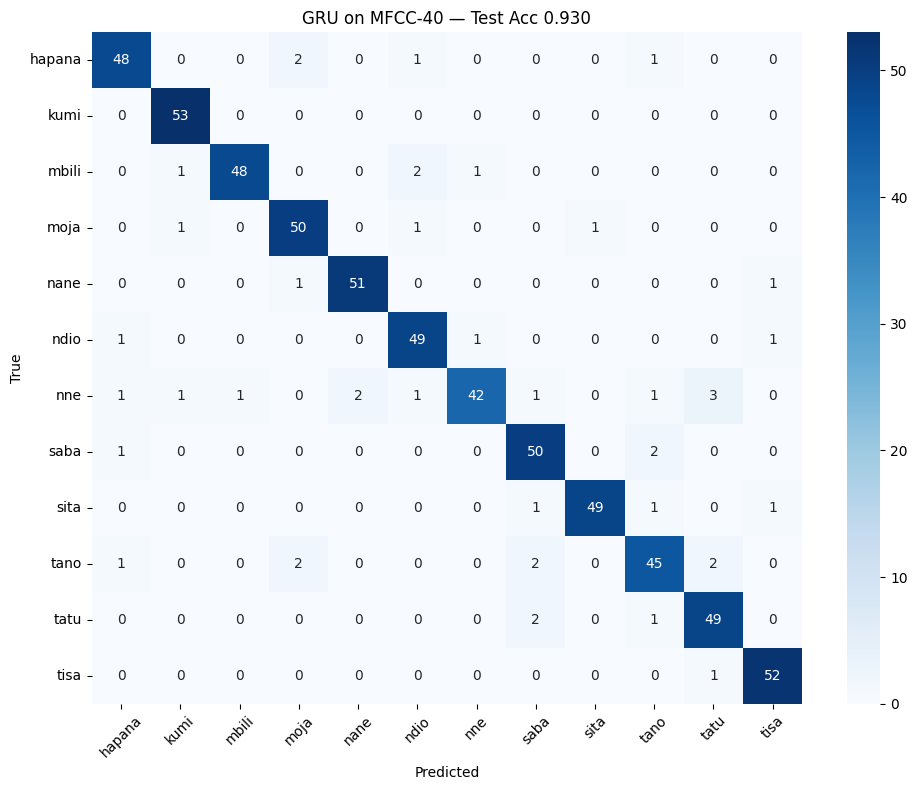

Test results CSV saved.


In [24]:
# ── Test-set evaluation on the labelled held-out split ──────────────────────
test_npz_reload = np.load(os.path.join(DATA_DIR, 'test.npz'), allow_pickle=True)
y_test = test_npz_reload['y']

y_pred_test = np.argmax(model.predict(X_test, verbose=0), axis=1)
test_acc = accuracy_score(y_test, y_pred_test)
test_f1  = f1_score(y_test, y_pred_test, average='macro')

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Macro-F1 : {test_f1:.4f}\n")
print(classification_report(y_test, y_pred_test, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'GRU on MFCC-40 — Test Acc {test_acc:.3f}')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{BASE}/results/gru_mfcc_test_confusion.png', dpi=150)
plt.show()

pd.DataFrame([{
    'model': 'GRU (MFCC-40)',
    'test_accuracy': test_acc,
    'test_macro_f1': test_f1,
}]).to_csv(f'{BASE}/results/gru_mfcc_test_results.csv', index=False)
print("Test results CSV saved.")


Test Accuracy : 0.9302
Test Macro-F1 : 0.9296

              precision    recall  f1-score   support

      hapana       0.92      0.92      0.92        52
        kumi       0.95      1.00      0.97        53
       mbili       0.98      0.92      0.95        52
        moja       0.91      0.94      0.93        53
        nane       0.96      0.96      0.96        53
        ndio       0.91      0.94      0.92        52
         nne       0.95      0.79      0.87        53
        saba       0.89      0.94      0.92        53
        sita       0.98      0.94      0.96        52
        tano       0.88      0.87      0.87        52
        tatu       0.89      0.94      0.92        52
        tisa       0.95      0.98      0.96        53

    accuracy                           0.93       630
   macro avg       0.93      0.93      0.93       630
weighted avg       0.93      0.93      0.93       630



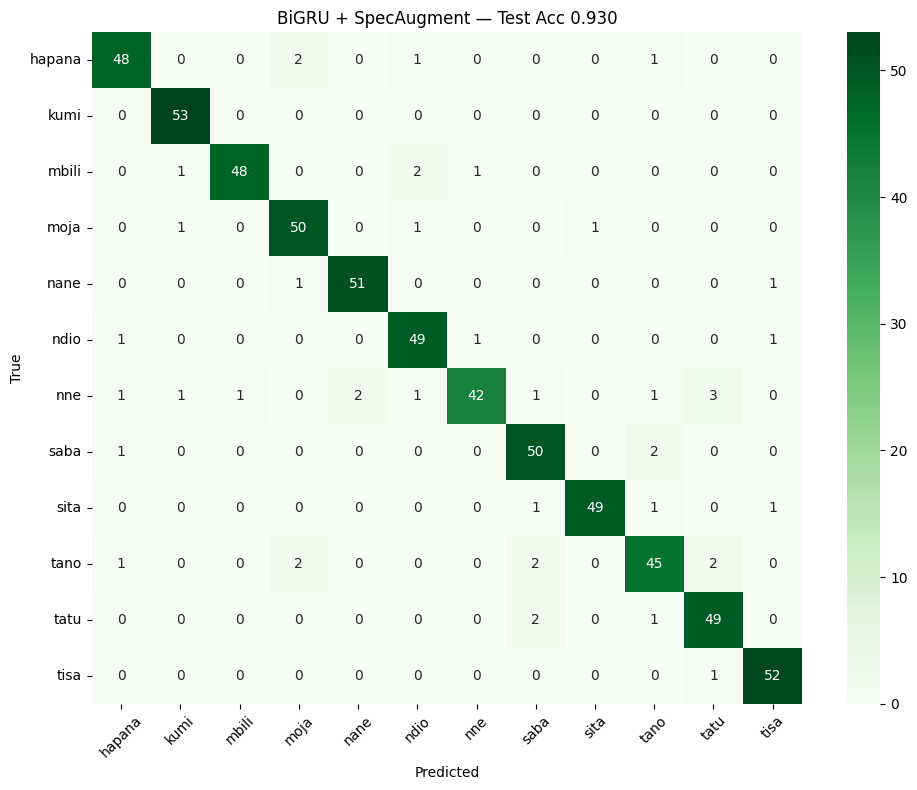

Test results CSV saved.


In [25]:
# ── Test-set evaluation on the labelled held-out split ──────────────────────
test_npz_reload = np.load(os.path.join(DATA_DIR, 'test.npz'), allow_pickle=True)
y_test = test_npz_reload['y']

y_pred_test = np.argmax(model.predict(X_test, verbose=0), axis=1)
test_acc = accuracy_score(y_test, y_pred_test)
test_f1  = f1_score(y_test, y_pred_test, average='macro')

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Macro-F1 : {test_f1:.4f}\n")
print(classification_report(y_test, y_pred_test, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'BiGRU + SpecAugment — Test Acc {test_acc:.3f}')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{BASE}/results/bigru_mfcc_test_confusion.png', dpi=150)
plt.show()

pd.DataFrame([{
    'model': 'BiGRU+SpecAugment (MFCC-40)',
    'test_accuracy': test_acc,
    'test_macro_f1': test_f1,
}]).to_csv(f'{BASE}/results/bigru_mfcc_test_results.csv', index=False)
print("Test results CSV saved.")
